Para la variable `summary` se decidió agrupar las categorías de muy baja frecuencia en una clase `"Otros"` y posteriormente aplicar One-Hot Encoding. Esta decisión se justifica porque `summary` es una variable categórica nominal, es decir, sus categorías no tienen un orden natural. El One-Hot Encoding permite representar cada estado climático como una variable binaria independiente, evitando introducir relaciones ordinales artificiales. Además, al agrupar categorías poco frecuentes se reduce la dimensionalidad y se evita que el modelo aprenda patrones inestables a partir de clases con muy pocos registros.

## Cargar dataset

Leemos el archivo de la capa **Trusted** generado en `EDAClima1_0.ipynb`. Usaremos la columna `summary` para revisar categorías antes del One-Hot Encoding.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUTA_MODELO = Path("../Datos/Trusted/clima_accidentes_modelo.csv")
COL_SUMMARY = "summary"
TARGET = "target"

df = pd.read_csv(RUTA_MODELO, parse_dates=["TW"])

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.columns.tolist()}")
df[[COL_SUMMARY, TARGET]].head()

Filas: 7,436,188
Columnas: ['TW', 'BARRIO', 'summary', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'uvIndex', 'target']


,summary,target
0,Partly Cloudy,0
1,Partly Cloudy,0
2,Foggy,0
3,Foggy,0
4,Foggy,0


## Revisión de `summary` (antes del One-Hot Encoding)

Antes de codificar, revisamos: valores nulos, número de categorías, frecuencia de cada clase, categorías raras y tasa de accidente (`target = 1`) por categoría. Esto permite decidir si conviene agrupar clases poco frecuentes.

RESUMEN DE LA COLUMNA summary
Registros totales:     7,436,188
Valores nulos:         0 (0.0000%)
Categorías distintas:  20
Tipo de dato:          str

Distribución de categorías (todas las filas):


,summary,cantidad,porcentaje,acumulado_%
0,Mostly Cloudy,2630239,35.3708,35.37
1,Partly Cloudy,1544022,20.7636,56.13
2,Possible Light Rain,1245280,16.7462,72.88
3,Overcast,1002614,13.4829,86.36
4,Rain,281200,3.7815,90.14
5,Clear,209775,2.8210,92.97
6,Possible Drizzle,172237,2.3162,95.28
7,Light Rain,144273,1.9401,97.22
8,Drizzle,138422,1.8615,99.08
9,Foggy,65649,0.8828,99.97



Categorías con menos del 0.1% de los datos (10):


,summary,cantidad,porcentaje,acumulado_%
10,Heavy Rain,2222,0.0299,100.0
11,Humid and Overcast,92,0.0012,100.0
12,Humid and Mostly Cloudy,79,0.0011,100.0
13,Windy and Partly Cloudy,39,0.0005,100.0
14,Windy and Mostly Cloudy,18,0.0002,100.0
15,Rain and Windy,9,0.0001,100.0
16,Humid,7,0.0001,100.0
17,Windy,5,0.0001,100.0
18,Possible Light Rain and Windy,4,0.0001,100.0
19,Humid and Partly Cloudy,2,0.0000,100.0



Tasa de accidente por categoría:


,summary,total_registros,accidentes,tasa_accidente,tasa_accidente_%,porcentaje_datos
9,Mostly Cloudy,2630239,42564,0.016183,1.6183,35.3708
11,Partly Cloudy,1544022,23185,0.015016,1.5016,20.7636
13,Possible Light Rain,1245280,18950,0.015217,1.5217,16.7462
10,Overcast,1002614,13813,0.013777,1.3777,13.4829
15,Rain,281200,4226,0.015028,1.5028,3.7815
0,Clear,209775,4228,0.020155,2.0155,2.8210
12,Possible Drizzle,172237,1993,0.011571,1.1571,2.3162
8,Light Rain,144273,1540,0.010674,1.0674,1.9401
1,Drizzle,138422,1561,0.011277,1.1277,1.8615
2,Foggy,65649,454,0.006916,0.6916,0.8828


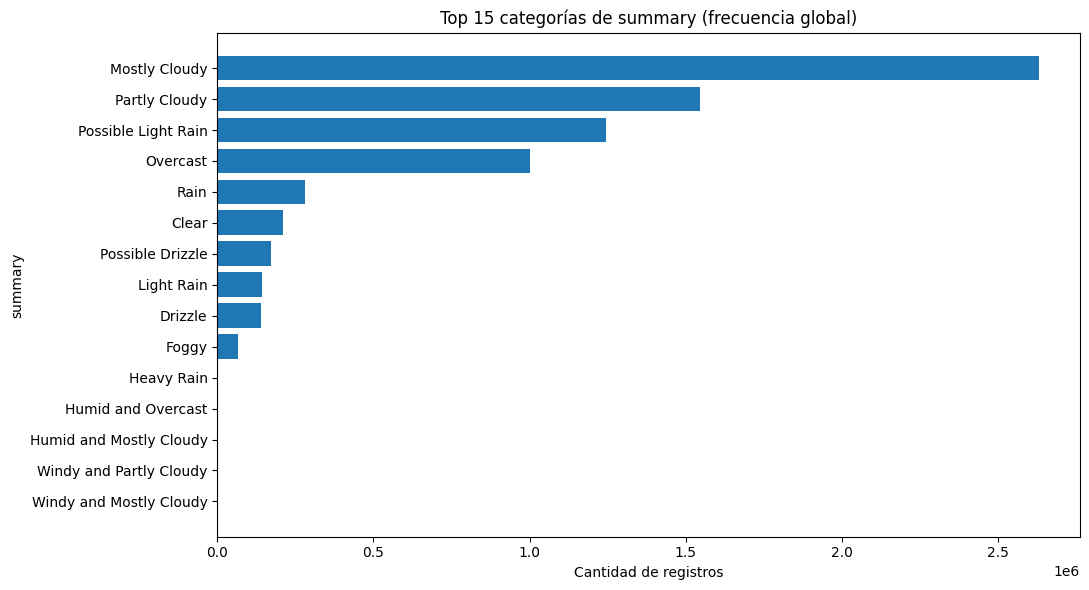

In [2]:
# --- Resumen general ---
n_filas = len(df)
n_nulos = df[COL_SUMMARY].isna().sum()
n_categorias = df[COL_SUMMARY].nunique(dropna=True)

print("=" * 70)
print("RESUMEN DE LA COLUMNA summary")
print("=" * 70)
print(f"Registros totales:     {n_filas:,}")
print(f"Valores nulos:         {n_nulos:,} ({n_nulos / n_filas * 100:.4f}%)")
print(f"Categorías distintas:  {n_categorias}")
print(f"Tipo de dato:          {df[COL_SUMMARY].dtype}")

# --- Frecuencia absoluta y relativa ---
freq_summary = (
    df[COL_SUMMARY]
    .value_counts(dropna=False)
    .rename_axis(COL_SUMMARY)
    .reset_index(name="cantidad")
)
freq_summary["porcentaje"] = (freq_summary["cantidad"] / n_filas * 100).round(4)
freq_summary["acumulado_%"] = freq_summary["porcentaje"].cumsum().round(2)

print("\nDistribución de categorías (todas las filas):")
display(freq_summary)

# --- Categorías raras (menos del 0.1 % del total) ---
UMBRAL_RARO_PCT = 0.1
raras = freq_summary[freq_summary["porcentaje"] < UMBRAL_RARO_PCT].copy()

print(f"\nCategorías con menos del {UMBRAL_RARO_PCT}% de los datos ({len(raras)}):")
display(raras)

# --- Tasa de accidente por categoría ---
tasa_por_categoria = (
    df.groupby(COL_SUMMARY, dropna=False)
    .agg(
        total_registros=(TARGET, "size"),
        accidentes=(TARGET, "sum"),
        tasa_accidente=(TARGET, "mean"),
    )
    .reset_index()
    .sort_values("total_registros", ascending=False)
)
tasa_por_categoria["tasa_accidente_%"] = (
    tasa_por_categoria["tasa_accidente"] * 100
).round(4)
tasa_por_categoria["porcentaje_datos"] = (
    tasa_por_categoria["total_registros"] / n_filas * 100
).round(4)

print("\nTasa de accidente por categoría:")
display(tasa_por_categoria)

# --- Gráfico: top categorías por volumen ---
top_n = 15
top_plot = freq_summary.head(top_n)

plt.figure(figsize=(11, 6))
plt.barh(top_plot[COL_SUMMARY].astype(str), top_plot["cantidad"])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} categorías de summary (frecuencia global)")
plt.xlabel("Cantidad de registros")
plt.ylabel("summary")
plt.tight_layout()
plt.show()

## Vista previa del agrupamiento (`summary_agrupado`)

Todas las categorías de `summary` con **menos de 93 registros** se agrupan en `"Otros"`. El umbral sale de la tabla de frecuencias: evita clases con muy pocos datos antes del One-Hot Encoding.

In [4]:
UMBRAL_REGISTROS = 93  # categorías con menos de 93 filas → "Otros"

conteo_categoria = df[COL_SUMMARY].value_counts()
categorias_otros = conteo_categoria[conteo_categoria < UMBRAL_REGISTROS].index.tolist()

print(f"Umbral: menos de {UMBRAL_REGISTROS} registros → 'Otros'")
print(f"Categorías agrupadas ({len(categorias_otros)}):")
for cat in categorias_otros:
    print(f"  - {cat}: {conteo_categoria[cat]:,}")

df["summary_agrupado"] = df[COL_SUMMARY].where(
    ~df[COL_SUMMARY].isin(categorias_otros),
    "Otros",
)

freq_agrupado = (
    df["summary_agrupado"]
    .value_counts(dropna=False)
    .rename_axis("summary_agrupado")
    .reset_index(name="cantidad")
)
freq_agrupado["porcentaje"] = (freq_agrupado["cantidad"] / len(df) * 100).round(4)

print("Comparación antes vs después del agrupamiento:")
print(f"  Categorías en summary:          {df[COL_SUMMARY].nunique(dropna=True)}")
print(f"  Categorías en summary_agrupado: {df['summary_agrupado'].nunique(dropna=True)}")

print("\nDistribución de summary_agrupado (columna candidata para OHE):")
display(freq_agrupado)

# Mapeo: qué valores originales quedaron en "Otros"
en_otros = (
    df.loc[df["summary_agrupado"] == "Otros", COL_SUMMARY]
    .value_counts()
    .rename_axis(COL_SUMMARY)
    .reset_index(name="cantidad")
)
print("\nValores originales de summary que se agruparon en 'Otros':")
display(en_otros)

Umbral: menos de 93 registros → 'Otros'
Categorías agrupadas (9):
  - Humid and Overcast: 92
  - Humid and Mostly Cloudy: 79
  - Windy and Partly Cloudy: 39
  - Windy and Mostly Cloudy: 18
  - Rain and Windy: 9
  - Humid: 7
  - Windy: 5
  - Possible Light Rain and Windy: 4
  - Humid and Partly Cloudy: 2
Comparación antes vs después del agrupamiento:
  Categorías en summary:          20
  Categorías en summary_agrupado: 12

Distribución de summary_agrupado (columna candidata para OHE):


,summary_agrupado,cantidad,porcentaje
0,Mostly Cloudy,2630239,35.3708
1,Partly Cloudy,1544022,20.7636
2,Possible Light Rain,1245280,16.7462
3,Overcast,1002614,13.4829
4,Rain,281200,3.7815
5,Clear,209775,2.8210
6,Possible Drizzle,172237,2.3162
7,Light Rain,144273,1.9401
8,Drizzle,138422,1.8615
9,Foggy,65649,0.8828



Valores originales de summary que se agruparon en 'Otros':


,summary,cantidad
0,Humid and Overcast,92
1,Humid and Mostly Cloudy,79
2,Windy and Partly Cloudy,39
3,Windy and Mostly Cloudy,18
4,Rain and Windy,9
5,Humid,7
6,Windy,5
7,Possible Light Rain and Windy,4
8,Humid and Partly Cloudy,2


## One-Hot Encoding de `summary_agrupado`

Cada categoría pasa a una columna binaria (`0` / `1`). Se eliminan `summary` y `summary_agrupado` para no duplicar la misma información. Con 12 clases, cada fila tiene exactamente un `1` en las columnas dummy.

In [5]:
import numpy as np

COL_AGRUPADO = "summary_agrupado"

# Columnas binarias (una por categoría)
dummies_summary = pd.get_dummies(
    df[COL_AGRUPADO],
    prefix="summary",
    dtype=np.uint8,
)
dummies_summary.columns = dummies_summary.columns.str.replace(" ", "_", regex=False)

cols_ohe = dummies_summary.columns.tolist()

# Dataset listo para modelado: numéricas + target + dummies
columnas_sin_categoricas = [
    c for c in df.columns if c not in (COL_SUMMARY, COL_AGRUPADO)
]
df_modelo = pd.concat([df[columnas_sin_categoricas], dummies_summary], axis=1)

# Validación: una sola categoría activa por fila
assert (dummies_summary.sum(axis=1) == 1).all(), "Cada fila debe tener exactamente un 1 en las dummies"

print(f"Columnas One-Hot creadas ({len(cols_ohe)}):")
for col in cols_ohe:
    print(f"  - {col}: {df_modelo[col].sum():,} unos")

print(f"\nForma final: {df_modelo.shape[0]:,} filas × {df_modelo.shape[1]} columnas")
print(f"Columnas: {df_modelo.columns.tolist()}")

display(df_modelo[cols_ohe].head())
display(df_modelo.head())

Columnas One-Hot creadas (12):
  - summary_Clear: 209,775 unos
  - summary_Drizzle: 138,422 unos
  - summary_Foggy: 65,649 unos
  - summary_Heavy_Rain: 2,222 unos
  - summary_Light_Rain: 144,273 unos
  - summary_Mostly_Cloudy: 2,630,239 unos
  - summary_Otros: 255 unos
  - summary_Overcast: 1,002,614 unos
  - summary_Partly_Cloudy: 1,544,022 unos
  - summary_Possible_Drizzle: 172,237 unos
  - summary_Possible_Light_Rain: 1,245,280 unos
  - summary_Rain: 281,200 unos

Forma final: 7,436,188 filas × 21 columnas
Columnas: ['TW', 'BARRIO', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'uvIndex', 'target', 'summary_Clear', 'summary_Drizzle', 'summary_Foggy', 'summary_Heavy_Rain', 'summary_Light_Rain', 'summary_Mostly_Cloudy', 'summary_Otros', 'summary_Overcast', 'summary_Partly_Cloudy', 'summary_Possible_Drizzle', 'summary_Possible_Light_Rain', 'summary_Rain']


,summary_Clear,summary_Drizzle,summary_Foggy,summary_Heavy_Rain,summary_Light_Rain,summary_Mostly_Cloudy,summary_Otros,summary_Overcast,summary_Partly_Cloudy,summary_Possible_Drizzle,summary_Possible_Light_Rain,summary_Rain
0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,0,0


,TW,BARRIO,temperature,dewPoint,humidity,windSpeed,windBearing,uvIndex,target,summary_Clear,...,summary_Foggy,summary_Heavy_Rain,summary_Light_Rain,summary_Mostly_Cloudy,summary_Otros,summary_Overcast,summary_Partly_Cloudy,summary_Possible_Drizzle,summary_Possible_Light_Rain,summary_Rain
0,2017-01-01 00:00:00,aguasfrias,16.43,14.0,0.86,1.50,0.0,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2017-01-01 01:00:00,aguasfrias,16.43,14.0,0.86,1.50,0.0,0.0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,2017-01-01 02:00:00,aguasfrias,15.43,13.0,0.85,1.02,90.0,0.0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,2017-01-01 03:00:00,aguasfrias,15.43,13.0,0.85,2.09,140.0,0.0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,2017-01-01 04:00:00,aguasfrias,15.43,13.0,0.85,2.09,350.0,0.0,0,0,...,1,0,0,0,0,0,0,0,0,0
